In [ ]:
import yfinance as yf
import pandas as pd

def update_database():
    # 1. Define the tickers
    # BTC-USD is for Bitcoin, SVXY for short volatility
    tickers = {
        'SPY': 'SPY - stocks',
        'GLD': 'GLD - gold',
        'DBC': 'DBC - commodities',
        'IEF': 'IEF - intermediate bonds',
        'TLT': 'TLT - long term bonds',
        'BTC-USD': 'BTC',
        'SVXY': 'SVXY'
    }

    print("Downloading Total Return data (Adjusted for Dividends)...")
    # auto_adjust=True pulls the dividend-reinvested prices
    data = yf.download(list(tickers.keys()), start="2011-08-18", auto_adjust=True)

    # 2. Extract the 'Close' column (which is now Adjusted)
    df = data['Close'].rename(columns=tickers)

    # 3. Clean up: Drop rows where we don't have data for all assets
    # (SVXY started in Oct 2011, so we start there)
    df = df.dropna().reset_index()
    df = df.rename(columns={'Date': 'time'})

    # 4. Save as your filename
    file_name = 'FINA4359 database +btc.csv'
    df.to_csv(file_name, index=False)

    print(f"Success! {file_name} created with Total Return data.")
    print(df.head())

if __name__ == "__main__":
    update_database()

[*********************100%***********************]  7 of 7 completed


Success! FINA4359 database +btc.csv created with Total Return data.
Ticker       time         BTC  DBC - commodities  GLD - gold  \
0      2014-09-17  457.334015          20.273592  117.540001   
1      2014-09-18  424.440002          20.079144  117.779999   
2      2014-09-19  394.795990          20.019962  117.089996   
3      2014-09-22  402.152008          19.850874  116.849998   
4      2014-09-23  435.790985          19.850874  117.599998   

Ticker  IEF - intermediate bonds  SPY - stocks       SVXY  \
0                      79.560547    164.567520  85.949997   
1                      79.506256    165.444641  87.190002   
2                      79.808609    165.295578  87.139999   
3                      79.979156    164.019012  84.120003   
4                      80.149727    163.080154  81.000000   

Ticker  TLT - long term bonds  
0                   82.256081  
1                   82.518600  
2                   83.568695  
3                   83.670815  
4                   

In [ ]:
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv('FINA4359 database +btc.csv')
df['time'] = pd.to_datetime(df['time'])

# 2. Define Assets (Core 5 Assets)
asset_cols = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
              'IEF - intermediate bonds', 'TLT - long term bonds','SVXY']

# 3. Calculate daily returns
returns = df.set_index('time')[asset_cols].pct_change().dropna()

# 4. Calculate SD for the WHOLE HISTORICAL period (Annualized)
# We calculate the standard deviation of the entire series at once
hist_std = returns.std() * np.sqrt(252)

# 5. Form Risk Parity Portfolio (Inverse Volatility)
inv_vol = 1 / hist_std
weights = inv_vol / inv_vol.sum()

# Summary
portfolio_summary = pd.DataFrame({
    'Full Hist. Annual SD (%)': (hist_std * 100).round(2),
    'Portfolio Weight (%)': (weights * 100).round(2)
})
print(portfolio_summary)

                          Full Hist. Annual SD (%)  Portfolio Weight (%)
SPY - stocks                                 17.62                 13.73
GLD - gold                                   15.93                 15.18
DBC - commodities                            17.84                 13.56
IEF - intermediate bonds                      6.57                 36.82
TLT - long term bonds                        14.86                 16.28
SVXY                                         54.48                  4.44


/tmp/ipykernel_1299/2076749822.py:64: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'], dayfirst=True)



BTC PERFORMANCE SUMMARY
                Strategy  Total Return (%)  CAGR (%)  Vol (%)  Sharpe  MDD (%)
        Market (S&P 500)            327.84     13.36    17.62    0.52   -33.72
     Typical AWP (Dalio)            101.41      6.23     8.51    0.23   -23.37
  Our Weighting (No BTC)             86.36      5.52     7.15    0.17   -17.56
Our Weighting (With BTC)            140.32      7.86     7.59    0.47   -18.95


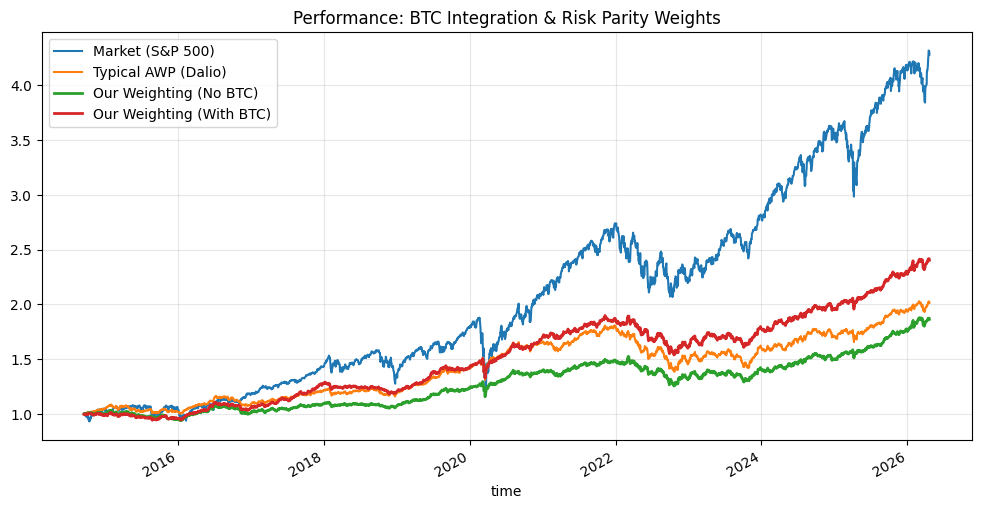

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_standardized_btc_analysis(file_path):
    # 1. Load and Clean Data
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]

    # Standardize BTC column name
    mapping = {'btc': 'BTC'}
    df = df.rename(columns=lambda x: mapping.get(x.lower(), x))

    # Convert time and set index
    df['time'] = pd.to_datetime(df['time'], dayfirst=True)
    df = df.set_index('time').sort_index()

    # Define Asset Groups
    core_assets = [
        'SPY - stocks',
        'GLD - gold',
        'DBC - commodities',
        'IEF - intermediate bonds',
        'TLT - long term bonds'
    ]
    btc_col = 'BTC'

    # 2. Calculate Daily Returns
    all_needed = core_assets + [btc_col]
    returns = df[all_needed].pct_change().dropna()

    # 3. Define Weighting Strategies
    # Strategy A: Typical AWP (Dalio Fixed Weights)
    w_dalio = pd.Series({
        'SPY - stocks': 0.30,
        'TLT - long term bonds': 0.40,
        'IEF - intermediate bonds': 0.15,
        'GLD - gold': 0.075,
        'DBC - commodities': 0.075
    }).reindex(core_assets)

    # Risk Parity Helper (Inverse Volatility Weighting)
    def get_inv_vol_weights(rets, asset_list):
        # Annualized Standard Deviation for the whole period
        vols = rets[asset_list].std() * np.sqrt(252)
        inv_vol = 1 / vols
        return inv_vol / inv_vol.sum()

    # Strategy B: Our Weighting (Risk Parity, No BTC)
    w_no_btc = get_inv_vol_weights(returns, core_assets)

    # Strategy C: Our Weighting (Risk Parity, With BTC)
    w_with_btc = get_inv_vol_weights(returns, core_assets + [btc_col])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_standardized_btc_analysis(file_path):
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]
    mapping = {'btc': 'BTC'}
    df = df.rename(columns=lambda x: mapping.get(x.lower(), x))
    df['time'] = pd.to_datetime(df['time'], dayfirst=True)
    df = df.set_index('time').sort_index()

    core = ['SPY - stocks', 'GLD - gold', 'DBC - commodities', 'IEF - intermediate bonds', 'TLT - long term bonds']
    btc_col = 'BTC'
    returns = df[core + [btc_col]].pct_change().dropna()

    def get_inv_vol_weights(rets, asset_list):
        vols = rets[asset_list].std() * np.sqrt(252)
        inv_vol = 1 / vols
        return inv_vol / inv_vol.sum()

    w_dalio = pd.Series({'SPY - stocks': 0.30, 'TLT - long term bonds': 0.40, 'IEF - intermediate bonds': 0.15, 'GLD - gold': 0.075, 'DBC - commodities': 0.075}).reindex(core)
    w_no_btc = get_inv_vol_weights(returns, core)
    w_with_btc = get_inv_vol_weights(returns, core + [btc_col])

    strat_rets = pd.DataFrame(index=returns.index)
    strat_rets['Market (S&P 500)'] = returns['SPY - stocks']
    strat_rets['Typical AWP (Dalio)'] = returns[core].dot(w_dalio)
    strat_rets['Our Weighting (No BTC)'] = returns[core].dot(w_no_btc)
    strat_rets['Our Weighting (With BTC)'] = returns[core + [btc_col]].dot(w_with_btc)

    def get_metrics(daily_rets, name, rf=4.28):
        cum_rets = (1 + daily_rets).cumprod()
        total_ret = (cum_rets.iloc[-1] - 1) * 100
        years = (cum_rets.index[-1] - cum_rets.index[0]).days / 365.25
        cagr = ((cum_rets.iloc[-1])**(1/years) - 1) * 100
        vol = daily_rets.std() * np.sqrt(252) * 100
        sharpe = (cagr - rf) / vol
        mdd = ((cum_rets / cum_rets.cummax()) - 1).min() * 100
        var_95 = np.percentile(daily_rets, 5) * 100
        return {"Strategy": name, "Total Return (%)": round(total_ret, 2), "CAGR (%)": round(cagr, 2),
                "Vol (%)": round(vol, 2), "Sharpe": round(sharpe, 2), "MDD (%)": round(mdd, 2)}

    stats = [get_metrics(strat_rets[col], col) for col in strat_rets.columns]
    print("\n" + "="*85 + "\nBTC PERFORMANCE SUMMARY\n" + "="*85)
    print(pd.DataFrame(stats).to_string(index=False))

    plt.figure(figsize=(12, 6))
    for col in strat_rets.columns:
        (1 + strat_rets[col]).cumprod().plot(label=col, linewidth=2 if "Our" in col else 1.5)
    plt.title('Performance: BTC Integration & Risk Parity Weights'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

run_standardized_btc_analysis('FINA4359 database +btc.csv')

/tmp/ipykernel_1299/1171124013.py:9: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'], dayfirst=True)
/tmp/ipykernel_1299/1171124013.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_1299/1171124013.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_1299/1171124013.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()


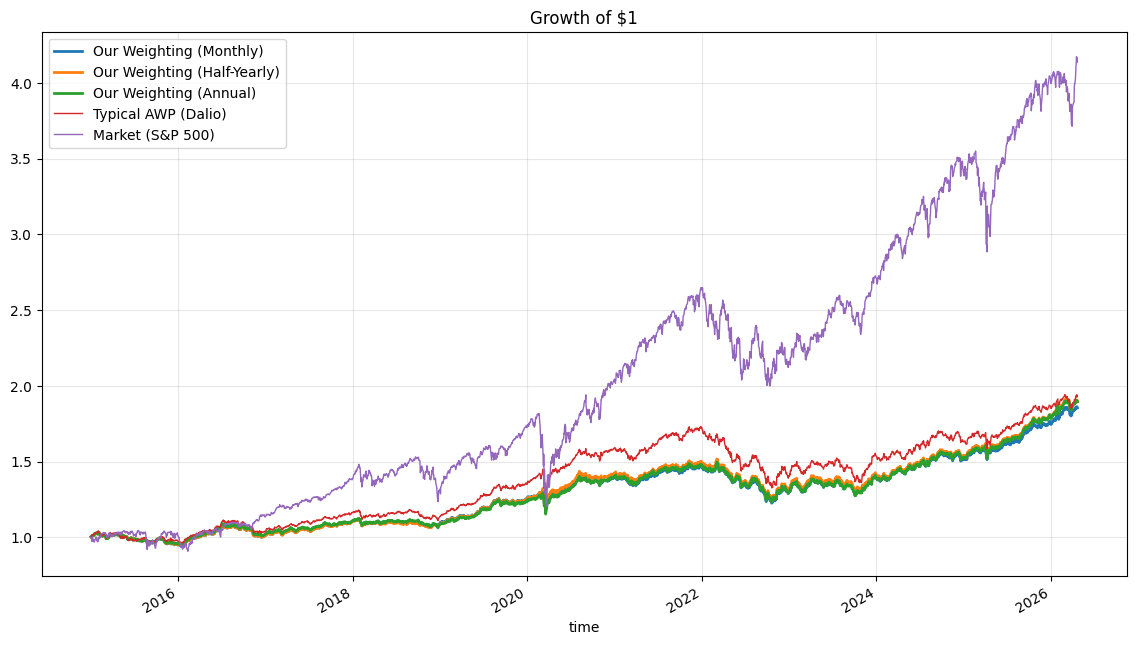

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_core_asset_analysis(file_path):
    # 1. Load and Clean Data
    df = pd.read_csv(file_path)
    df.columns = [c.strip() for c in df.columns]
    df['time'] = pd.to_datetime(df['time'], dayfirst=True)
    df = df.set_index('time').sort_index()

    core_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities',
                   'IEF - intermediate bonds', 'TLT - long term bonds']
    returns = df[core_assets].pct_change().dropna()

    # 2. Rebalancing logic with 2014 Seed
    def backtest_from_2015(returns_df, asset_list, frequency='Y', lookback=252):
        ret_sub = returns_df[asset_list]
        start_2015 = ret_sub.index[ret_sub.index.year >= 2015][0]
        rebal_dates = ret_sub.index.to_series().resample(frequency).last()

        port_returns = pd.Series(index=ret_sub.loc[start_2015:].index, dtype=float)
        current_weights = None

        for i in range(len(ret_sub)):
            date = ret_sub.index[i]
            # Initial weight using 2014 data
            if date == start_2015:
                window = ret_sub.loc[:start_2015].iloc[:-1]
                vols = window.std() * np.sqrt(252)
                current_weights = (1/vols) / (1/vols).sum()
            # Standard rebalancing
            elif date > start_2015 and date in rebal_dates.values:
                idx = ret_sub.index.get_loc(date)
                window = ret_sub.iloc[max(0, idx - lookback) : idx]
                vols = window.std() * np.sqrt(252)
                current_weights = (1/vols) / (1/vols).sum()

            if date >= start_2015 and current_weights is not None:
                port_returns.loc[date] = (ret_sub.loc[date] * current_weights).sum()
        return port_returns

    # 3. Generating Frequencies
    results = {f'Our Weighting ({n})': backtest_from_2015(returns, core_assets, f)
               for f, n in [('M', 'Monthly'), ('6M', 'Half-Yearly'), ('Y', 'Annual')]}

    # Benchmarks
    s_date = results['Our Weighting (Annual)'].index[0]
    results['Typical AWP (Dalio)'] = returns[core_assets].dot([0.3, 0.075, 0.075, 0.15, 0.4]).loc[s_date:]
    results['Market (S&P 500)'] = returns['SPY - stocks'].loc[s_date:]

    # 4. Visualization
    plt.figure(figsize=(14, 8))
    for name, rets in results.items():
        (1 + rets).cumprod().plot(label=name, linewidth=2 if "Our" in name else 1)
    plt.title('Growth of $1'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

run_core_asset_analysis('FINA4359 database +btc.csv')

/tmp/ipykernel_1299/4264791950.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'], dayfirst=True)


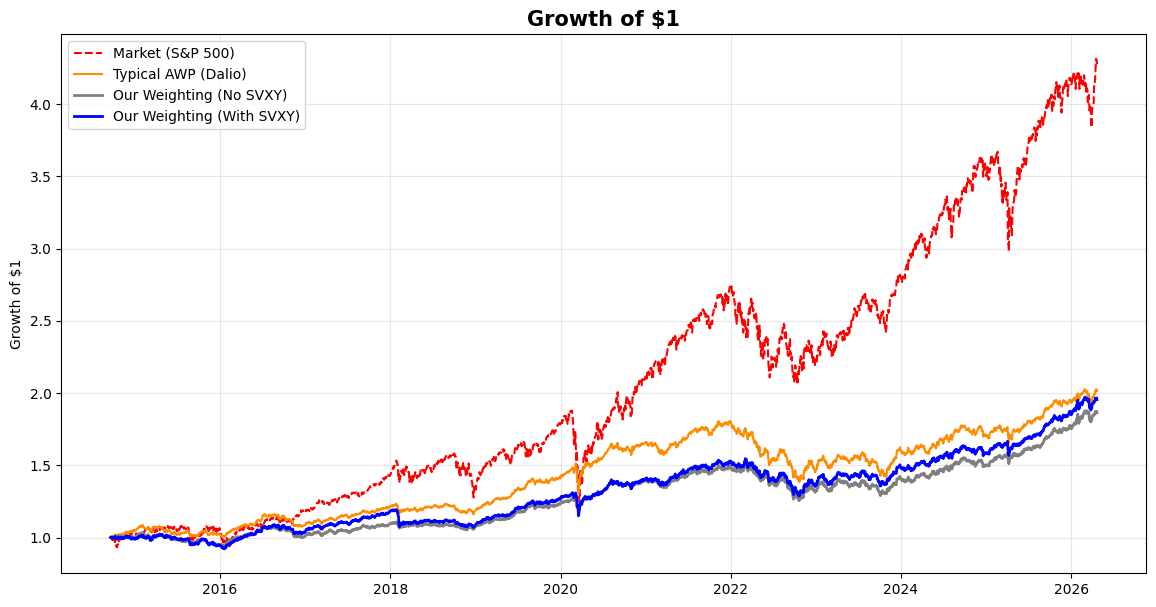

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Return Calculation ---
df = pd.read_csv('FINA4359 database +btc.csv')
df['time'] = pd.to_datetime(df['time'], dayfirst=True)
df = df.set_index('time').sort_index()

core = ['SPY - stocks', 'GLD - gold', 'DBC - commodities', 'IEF - intermediate bonds', 'TLT - long term bonds']
svxy = 'SVXY'
returns = df[core + [svxy]].pct_change().dropna()

# --- 2. Weighting Strategies ---
hist_std = returns.std() * np.sqrt(252)

# A: Typical Dalio (Fixed)
w_dalio = pd.Series({'SPY - stocks': 0.30, 'TLT - long term bonds': 0.40,
                    'IEF - intermediate bonds': 0.15, 'GLD - gold': 0.075,
                    'DBC - commodities': 0.075}).reindex(core)

# B: Our Weighting (Risk Parity, No SVXY)
inv_vol_no_svxy = 1 / hist_std[core]
w_no_svxy = inv_vol_no_svxy / inv_vol_no_svxy.sum()

# C: Our Weighting (Risk Parity, With SVXY)
inv_vol_with_svxy = 1 / hist_std[core + [svxy]]
w_with_svxy = inv_vol_with_svxy / inv_vol_with_svxy.sum()

# --- 3. Generate Returns ---
strat_rets = {
    "Market (S&P 500)": returns['SPY - stocks'],
    "Typical AWP (Dalio)": returns[core].dot(w_dalio),
    "Our Weighting (No SVXY)": returns[core].dot(w_no_svxy),
    "Our Weighting (With SVXY)": returns[core + [svxy]].dot(w_with_svxy)
}

# --- 4. Plotting Evolution ---
plt.figure(figsize=(14, 7))
colors = ["red", "darkorange", "grey", "blue"]
linestyles = ["--", "-", "-", "-"]

for (name, series), color, ls in zip(strat_rets.items(), colors, linestyles):
    cum = (1 + series).cumprod()
    plt.plot(cum, label=name, color=color, linestyle=ls, linewidth=2 if "Our" in name else 1.5)

plt.title('Growth of $1', fontsize=15, fontweight='bold')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1299/2157959357.py:76: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'], dayfirst=True)
/tmp/ipykernel_1299/2157959357.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_1299/2157959357.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_1299/2157959357.py:17: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  rebal_dates = ret_sub.index.to_series().resample(frequency).last()
/tmp/ipykernel_1299/2157959357.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  r

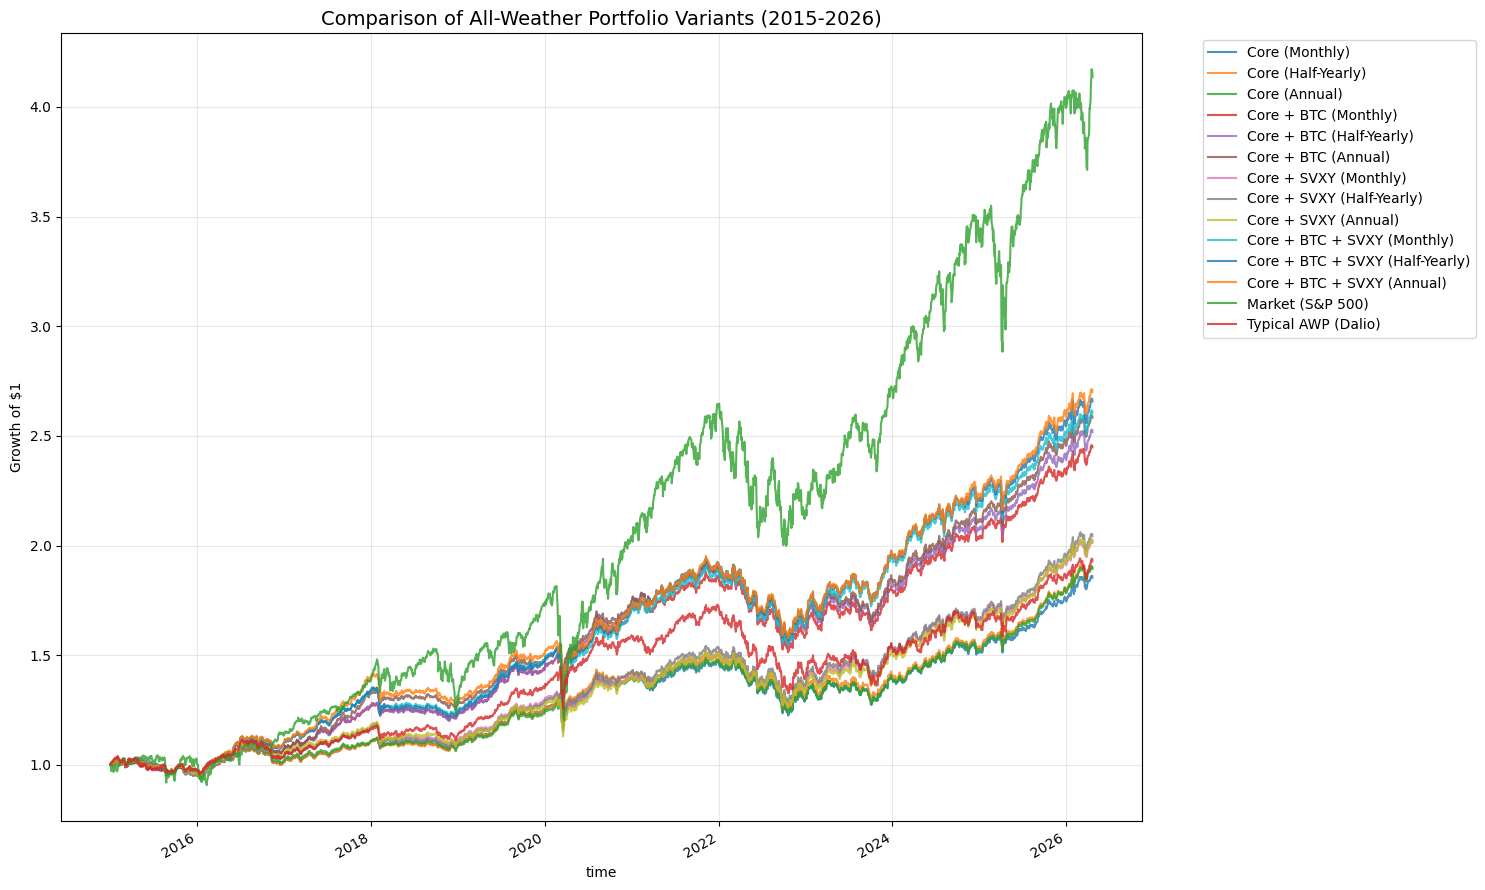

                       Strategy  Total Return (%)  CAGR (%)  Vol (%)  Sharpe  MDD (%)
     Core + BTC + SVXY (Annual)            170.07      9.19     8.24    0.60   -19.30
Core + BTC + SVXY (Half-Yearly)            165.72      9.03     8.11    0.59   -19.26
            Core + BTC (Annual)            158.37      8.76     7.68    0.58   -19.54
    Core + BTC + SVXY (Monthly)            160.48      8.84     8.09    0.56   -19.07
       Core + BTC (Half-Yearly)            151.81      8.52     7.59    0.56   -19.56
           Core + BTC (Monthly)            144.79      8.25     7.56    0.52   -19.40
               Market (S&P 500)            313.64     13.39    17.71    0.51   -33.72
      Core + SVXY (Half-Yearly)            104.36      6.53     7.68    0.29   -17.09
          Core + SVXY (Monthly)            101.27      6.39     7.65    0.28   -16.86
           Core + SVXY (Annual)            102.04      6.42     7.79    0.27   -17.05
             Core (Half-Yearly)             89.87     

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def backtest_risk_parity(returns_df, asset_list, frequency='Y', lookback=252):
    """
    Backtests an inverse-volatility (Risk Parity) strategy.
    - frequency: 'M' (Monthly), '6M' (Half-Yearly), 'Y' (Annual)
    - Starts Jan 2015 using 2014 data as the initial volatility seed.
    """
    ret_sub = returns_df[asset_list]

    # Identify the first trading day of 2015
    start_2015 = ret_sub.index[ret_sub.index.year >= 2015][0]

    # Generate rebalancing schedule
    rebal_dates = ret_sub.index.to_series().resample(frequency).last()

    port_returns = pd.Series(index=ret_sub.loc[start_2015:].index, dtype=float)
    current_weights = None

    for i in range(len(ret_sub)):
        date = ret_sub.index[i]

        # 1. INITIAL SEED: At the start of 2015, use all 2014 data for weights
        if date == start_2015:
            window = ret_sub.loc[:start_2015].iloc[:-1]
            vols = window.std() * np.sqrt(252)
            # Prevent division by zero
            vols = vols.replace(0, np.nan).fillna(vols.mean()).fillna(0.01)
            inv_vol = 1 / vols
            current_weights = inv_vol / inv_vol.sum()

        # 2. REBALANCE: Update weights on scheduled dates
        elif date > start_2015 and date in rebal_dates.values:
            idx = ret_sub.index.get_loc(date)
            window = ret_sub.iloc[max(0, idx - lookback) : idx]
            vols = window.std() * np.sqrt(252)
            vols = vols.replace(0, np.nan).fillna(vols.mean()).fillna(0.01)
            inv_vol = 1 / vols
            current_weights = inv_vol / inv_vol.sum()

        # 3. APPLY: Calculate daily portfolio return
        if date >= start_2015 and current_weights is not None:
            port_returns.loc[date] = (ret_sub.loc[date] * current_weights).sum()

    return port_returns.dropna()

def calculate_metrics(daily_rets, name, rf_rate=4.28):
    """Calculates key performance indicators."""
    cum_growth = (1 + daily_rets).cumprod()
    total_ret = (cum_growth.iloc[-1] - 1) * 100

    years = (cum_growth.index[-1] - cum_growth.index[0]).days / 365.25
    cagr = ((cum_growth.iloc[-1])**(1/years) - 1) * 100

    vol = daily_rets.std() * np.sqrt(252) * 100
    sharpe = (cagr - rf_rate) / vol
    mdd = ((cum_growth / cum_growth.cummax()) - 1).min() * 100

    return {
        "Strategy": name,
        "Total Return (%)": round(total_ret, 2),
        "CAGR (%)": round(cagr, 2),
        "Vol (%)": round(vol, 2),
        "Sharpe": round(sharpe, 2),
        "MDD (%)": round(mdd, 2)
    }

# --- MAIN EXECUTION ---

# 1. Load Data
file_path = 'FINA4359 database +btc.csv'
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]
df['time'] = pd.to_datetime(df['time'], dayfirst=True)
df = df.set_index('time').sort_index()

# 2. Asset Universes
core_assets = ['SPY - stocks', 'GLD - gold', 'DBC - commodities', 'IEF - intermediate bonds', 'TLT - long term bonds']
btc = ['BTC']
svxy = ['SVXY']

returns = df[core_assets + btc + svxy].pct_change().dropna()

# 3. Combinations & Frequencies
combos = {
    "Core": core_assets,
    "Core + BTC": core_assets + btc,
    "Core + SVXY": core_assets + svxy,
    "Core + BTC + SVXY": core_assets + btc + svxy
}
frequencies = [('M', 'Monthly'), ('6M', 'Half-Yearly'), ('Y', 'Annual')]

results = {}

# Run Dynamic Backtests
for label, assets in combos.items():
    for f_code, f_label in frequencies:
        name = f"{label} ({f_label})"
        results[name] = backtest_risk_parity(returns, assets, frequency=f_code)

# Run Static Benchmarks
start_date = results['Core (Annual)'].index[0]
results['Market (S&P 500)'] = returns['SPY - stocks'].loc[start_date:]

dalio_weights = pd.Series({
    'SPY - stocks': 0.30, 'TLT - long term bonds': 0.40, 'IEF - intermediate bonds': 0.15,
    'GLD - gold': 0.075, 'DBC - commodities': 0.075
}).reindex(core_assets)
results['Typical AWP (Dalio)'] = returns[core_assets].dot(dalio_weights).loc[start_date:]

# 4. Visualization & Stats
plt.figure(figsize=(15, 9))
summary_stats = []

for name, s_rets in results.items():
    # Plotting
    (1 + s_rets).cumprod().plot(label=name, alpha=0.8)
    # Metrics
    summary_stats.append(calculate_metrics(s_rets, name))

plt.title('Comparison of All-Weather Portfolio Variants (2015-2026)', fontsize=14)
plt.ylabel('Growth of $1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print Table
stats_df = pd.DataFrame(summary_stats)
print(stats_df.sort_values('Sharpe', ascending=False).to_string(index=False))

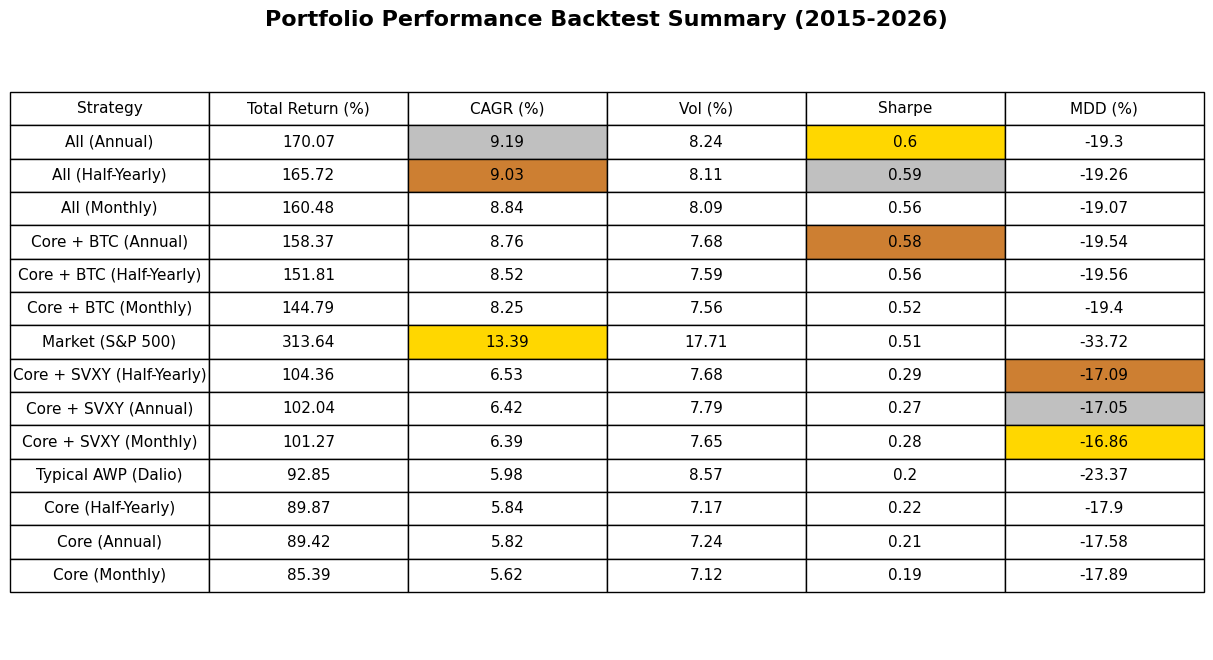

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ["All (Annual)", 170.07, 9.19, 8.24, 0.60, -19.30],
    ["All (Half-Yearly)", 165.72, 9.03, 8.11, 0.59, -19.26],
    ["All (Monthly)", 160.48, 8.84, 8.09, 0.56, -19.07],
    ["Core + BTC (Annual)", 158.37, 8.76, 7.68, 0.58, -19.54],
    ["Core + BTC (Half-Yearly)", 151.81, 8.52, 7.59, 0.56, -19.56],
    ["Core + BTC (Monthly)", 144.79, 8.25, 7.56, 0.52, -19.40],
    ["Market (S&P 500)", 313.64, 13.39, 17.71, 0.51, -33.72],
    ["Core + SVXY (Half-Yearly)", 104.36, 6.53, 7.68, 0.29, -17.09],
    ["Core + SVXY (Annual)", 102.04, 6.42, 7.79, 0.27, -17.05],
    ["Core + SVXY (Monthly)", 101.27, 6.39, 7.65, 0.28, -16.86],
    ["Typical AWP (Dalio)", 92.85, 5.98, 8.57, 0.20, -23.37],
    ["Core (Half-Yearly)", 89.87, 5.84, 7.17, 0.22, -17.90],
    ["Core (Annual)", 89.42, 5.82, 7.24, 0.21, -17.58],
    ["Core (Monthly)", 85.39, 5.62, 7.12, 0.19, -17.89]
]

columns = ["Strategy", "Total Return (%)", "CAGR (%)", "Vol (%)", "Sharpe", "MDD (%)"]
df = pd.DataFrame(data, columns=columns)

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Color logic for highlighting
cell_colors = [["#ffffff"] * len(columns) for _ in range(len(df))]
def highlight_top_3(col_idx, ascending=False):
    ranks = df.iloc[:, col_idx].rank(ascending=ascending, method='min')
    for i, rank in enumerate(ranks):
        if rank == 1: cell_colors[i][col_idx] = "#FFD700"  # Gold
        elif rank == 2: cell_colors[i][col_idx] = "#C0C0C0" # Silver
        elif rank == 3: cell_colors[i][col_idx] = "#CD7F32" # Bronze

highlight_top_3(2) # CAGR
highlight_top_3(4) # Sharpe
highlight_top_3(5, ascending=False) # MDD (Best is least negative)

table = ax.table(cellText=df.values, colLabels=df.columns,
                 cellColours=cell_colors, loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2)

plt.title("Portfolio Performance Backtest Summary (2015-2026)", fontsize=16, fontweight='bold')
plt.show()